In [1]:
import ChessLens

from matplotlib import pyplot as plt
import numpy as np
import cv2

import torch

from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [2]:
dataset = ChessDataset(
    config={
        "img_size": (640,640)
    }
)
dataloader = ChessDataset.getLoader(dataset, batch_size=4, num_worders=0)

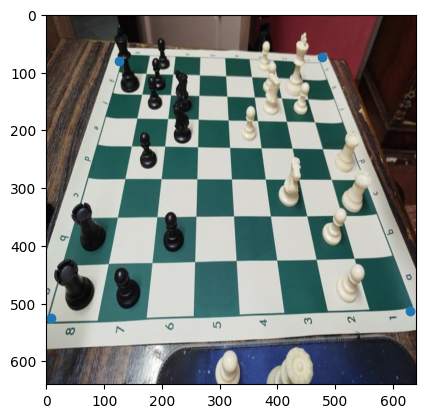

In [3]:
# for img, label in dataset:
    # _, H, W = img.shape
    # print(label)
    # plt.imshow(img.permute(1,2,0));
    # plt.scatter(label["corners"][:,0], label["corners"][:,1])

    # print(H, W)
    # break

# img, _ = dataset[50]
img, _ = dataset[278]

# img = ChessLens.ChessLensImage("./Dataset/img_3.jpeg")
img = ChessLens.ChessLensImage(img, "yolo")
img.detect_board()
_, H, W = img.img.shape
label = {
    "corners": img.board_detection
}

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);

In [4]:
s = 0
cx = W/2
cy = H/2

In [5]:
# fx = 2739.79 * 640 / 2304
# fy = 2739.79 * 640/1728
fx = 2739.79 * W/4032
fy = 2739.79 * H/3024

K = np.array([
    [fx, s, cx],
    [0, fy, cy],
    [0,  0,  1]
]) # K: intrinsics of 3d -> 2d

In [6]:
cam_point = np.array([0,0,.5])
Z = cam_point[2]

def extrinsics_from_planar_points(image_pts, K, L=1.0):
    """
    image_pts: (4,2) image coordinates in pixels, in known order (clockwise or ccw)
    K: 3x3 camera intrinsics
    L: side length of the square in world coordinates (any unit)
    Returns:
        R: 3x3 rotation matrix (world→camera)
        t: 3x1 translation vector (world→camera)
        H: 3x3 homography (plane→image)
    """
    # Define square points on the world plane Z=0
    world_pts = np.array([
        [0, 0],
        [L, 0],
        [L, L],
        [0, L]
    ], dtype=np.float64)

    # Find homography (plane -> image)
    H, _ = cv2.findHomography(world_pts, image_pts)

    # Decompose using intrinsics
    K_inv = np.linalg.inv(K)
    h1, h2, h3 = H[:,0], H[:,1], H[:,2]

    # Normalize rotation columns
    lam = 1.0 / np.linalg.norm(K_inv @ h1)
    r1 = lam * (K_inv @ h1)
    r2 = lam * (K_inv @ h2)
    r3 = np.cross(r1, r2)

    R = np.column_stack((r1, r2, r3))
    # Enforce orthonormality via SVD
    U, _, Vt = np.linalg.svd(R)
    R = U @ Vt

    # Ensure a right-handed coordinate system
    if np.linalg.det(R) < 0:
        R[:, 2] *= -1

    t = lam * (K_inv @ h3)
    return R, t.reshape(3,1), H


# r_val = 1/np.sqrt(2)
# R_ = np.array([
#     [1, 0, 0],
#     [0, -r_val, -r_val],
#     [0, r_val, -r_val],
# ])

R_, t, H = extrinsics_from_planar_points(img.board_detection.numpy(), K, 1)
pitch = np.degrees(np.arctan2(R_[2,1], R_[1,1]))
print(pitch)

t = (-R_) @ cam_point.reshape((3,1))
# t = np.array([
#     [0],
#     [-Z * r_val],
#     [Z * r_val]
# ])

R = np.concat([R_, t], axis=1)
R = np.concat([R, np.array([[0,0,0,1]])], axis=0) # R: extrinsics of World -> Camera

-35.23570511253303


In [7]:
def from_3d_to_2d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ R.T
    res_points = (res_points / res_points[:,[3]])[:, :3]
    res_points = res_points @ K.T
    res_points = (res_points/res_points[:, [2]])[:, :2]
    return res_points

def from_2d_to_3d(points: np.ndarray, K: np.ndarray, R: np.ndarray):
    N = points.shape[0]
    points_ = np.concat([points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(K).T

    points_ = np.concat([res_points, np.ones((N, 1))], axis=1)
    res_points = points_ @ np.linalg.inv(R).T
    res_points = (res_points/res_points[:, [3]])[:, :3]

    return res_points

def trace_ray(directions: np.ndarray, cam_point: np.ndarray, Z_0: np.ndarray):
    N = directions.shape[0]
    if directions.shape[1] != 3 or len(directions.shape) != 2 \
        or cam_point.shape[0] != 3 or len(cam_point.shape) != 1 \
        or Z_0.shape[0] != N or len(Z_0.shape) != 1:
        raise Exception("Invalid input")
    
    t = ((Z_0-cam_point[2]) / (directions[:, 2] - cam_point[2]))
    p = cam_point + t.reshape(N, 1) * (directions - cam_point.reshape(1,3))
    return p

p = np.array([
    [1,2,3],
    [4,5,10]
])
print(p)
p1 = from_3d_to_2d(p, K, R)
print(p1)
p2 = from_2d_to_3d(p1, K, R)
print(p2)
p3 = trace_ray(p2, cam_point, np.array([3, 10]))
print(p3)

[[ 1  2  3]
 [ 4  5 10]]
[[     845.61      2283.3]
 [     695.65      1432.8]]
[[     1.1125      2.2251      3.2813]
 [    0.81352      1.0169      2.4321]]
[[          1           2           3]
 [          4           5          10]]


In [8]:
label["corners"]

tensor([[126.,  79.],
        [477.,  72.],
        [629., 513.],
        [  8., 524.]])

In [9]:
corners_3d = trace_ray(from_2d_to_3d(label["corners"].numpy(), K, R), cam_point, np.zeros((4)))
corners_3d

array([[    0.36927,     0.81161,           0],
       [   -0.33457,      0.7969,           0],
       [   -0.34929,     0.13921,           0],
       [    0.35455,     0.15392,           0]])

In [10]:
corners_up_2d = from_3d_to_2d(corners_3d, K, R)
corners_up_2d

array([[        126,          79],
       [        477,          72],
       [        629,         513],
       [          8,         524]])

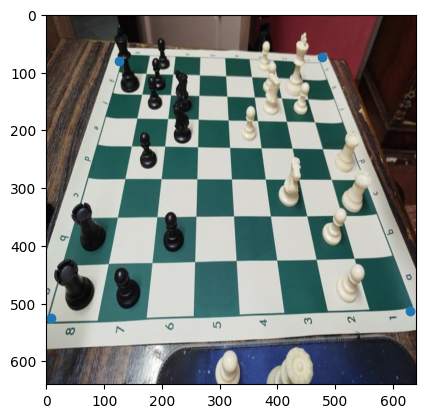

In [11]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(corners_up_2d[:,0], corners_up_2d[:,1]);

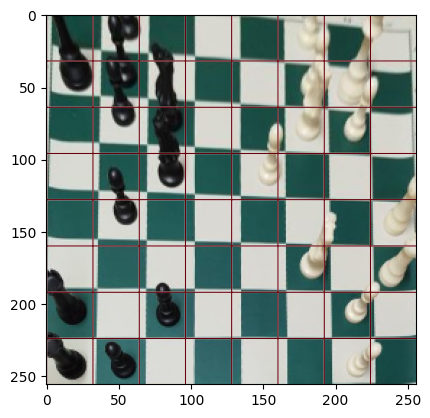

In [26]:
dst = np.array([
    [0,0],
    [256,0],
    [256,256],
    [0,256],
], dtype=np.float32)
pad = (0,0)
dst[:,0] += pad[0]
dst[:,1] += pad[1]

M = cv2.getPerspectiveTransform(img.board_detection.cpu().numpy().astype(np.float32), dst)
M = torch.tensor(M)

warpped_img = cv2.warpPerspective(img.img.permute(1,2,0).numpy(), M.numpy(), (256+2*pad[0],256+2*pad[1]))
plt.imshow(warpped_img);

grid = np.zeros((256+2*pad[0],256+2*pad[1]))
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha = grid, cmap="Reds");

In [27]:
r = 2
c = 2

In [28]:
sq_box = np.array([
    [(c-1)*32, (r-1)*32],
    [(c)*32, (r-1)*32],
    [(c)*32, (r)*32],
    [(c-1)*32, (r)*32],
], dtype=np.float32)

In [29]:
M_inv = np.linalg.inv(M)

inverted_sq = []

for i in range(len(sq_box)):
    inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))
    inverted_sq[-1] = (inverted_sq[-1] / inverted_sq[-1][2])[:2]

inverted_sq = np.stack(inverted_sq, axis=0)
inverted_sq

/tmp/ipykernel_247334/1142479384.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  inverted_sq.append(M_inv @ np.concat([sq_box[i], np.ones(1)], axis=0))


array([[      163.5,      111.35],
       [     209.84,      110.44],
       [     205.59,      147.67],
       [     156.42,      148.63]])

In [30]:
pts = trace_ray(from_2d_to_3d(inverted_sq, K, R), cam_point, np.zeros(4)) + np.concat([np.zeros((4,2)), .1*np.ones((4,1))], axis=1)
pts2 = from_3d_to_2d(pts, K, R)

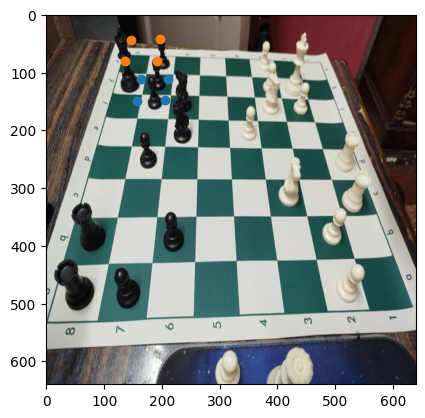

In [31]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(inverted_sq[:,0], inverted_sq[:,1]);
plt.scatter(pts2[:,0], pts2[:,1]);

In [32]:
xs = np.linspace(0,256, 9)
ys = np.linspace(0,256, 9)

X, Y = np.meshgrid(xs, ys)
points = np.stack([X,Y], axis=2)

points.shape, X.shape, Y.shape, points[3,6]

((9, 9, 2), (9, 9), (9, 9), array([        192,          96]))

In [33]:
tmp = np.concat([points, np.ones((9,9,1))], axis=2) @ M_inv.numpy().T

tmp = (tmp/tmp[:, :, [2]])[:, :, :2].reshape(-1, 2)
tmp

array([[        126,          79],
       [     169.81,      78.126],
       [     213.63,      77.252],
       [     257.48,      76.378],
       [     301.35,      75.503],
       [     345.23,      74.628],
       [     389.13,      73.752],
       [     433.06,      72.876],
       [        477,          72],
       [     117.18,      112.27],
       [      163.5,      111.35],
       [     209.84,      110.44],
       [      256.2,      109.52],
       [     302.59,       108.6],
       [        349,      107.69],
       [     395.43,      106.77],
       [     441.88,      105.85],
       [     488.35,      104.93],
       [     107.28,      149.59],
       [     156.42,      148.63],
       [     205.59,      147.67],
       [     254.77,       146.7],
       [     303.99,      145.74],
       [     353.23,      144.78],
       [     402.49,      143.81],
       [     451.77,      142.85],
       [     501.09,      141.88],
       [       96.1,      191.76],
       [     148.43,

In [34]:
elevated_tmp = trace_ray(from_2d_to_3d(tmp, K, R), cam_point, np.zeros((81)))
elevated_tmp += np.concat([np.zeros((81,2)), .1*np.ones((81, 1))], axis=1)
elevated_tmp = from_3d_to_2d(elevated_tmp, K, R)
elevated_tmp

array([[     105.42,       11.85],
       [     153.75,       10.87],
       [      202.1,      9.8893],
       [     250.48,      8.9081],
       [     298.87,      7.9265],
       [     347.29,      6.9444],
       [     395.74,      5.9618],
       [     444.21,      4.9787],
       [      492.7,      3.9951],
       [     94.323,      44.497],
       [     145.73,      43.462],
       [     197.16,      42.428],
       [     248.61,      41.392],
       [      300.1,      40.356],
       [     351.61,       39.32],
       [     403.15,      38.283],
       [     454.71,      37.246],
       [      506.3,      36.208],
       [     81.709,      81.586],
       [     136.61,      80.492],
       [     191.54,      79.397],
       [      246.5,      78.301],
       [     301.49,      77.205],
       [     356.51,      76.108],
       [     411.56,      75.011],
       [     466.64,      73.913],
       [     521.76,      72.814],
       [     67.254,      124.09],
       [     126.16,

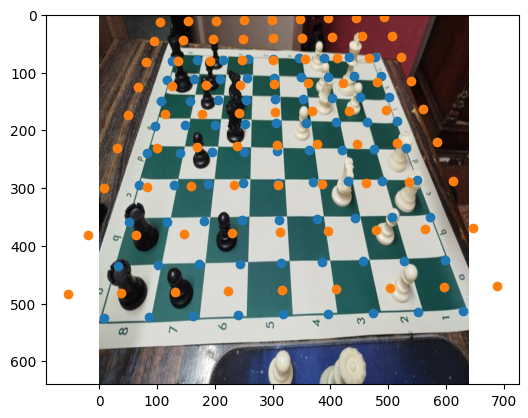

In [35]:
plt.imshow(img.img.permute(1,2,0));
plt.scatter(tmp[:,0], tmp[:,1]);
plt.scatter(elevated_tmp[:,0], elevated_tmp[:,1]);

(640, 640, 3) uint8


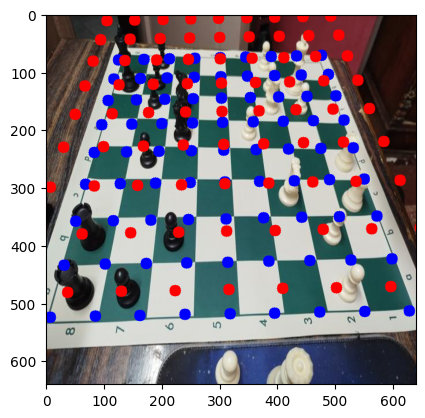

In [65]:
tmp_img = (img.img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
tmp_img = np.ascontiguousarray(tmp_img)
print(tmp_img.shape, tmp_img.dtype)
for x, y in tmp:
    tmp_img = cv2.circle(tmp_img, (int(x), int(y)), radius=10, color=(0,0,255), thickness=-1)
for x, y in elevated_tmp:
    tmp_img = cv2.circle(tmp_img, (int(x), int(y)), radius=10, color=(255,0,0), thickness=-1)

plt.imshow(torch.tensor(tmp_img));